# Credit Default Risk Assessment

## Data Loading and Initial Exploration

The objective of this analysis is to study customer financial behavior patterns and build predictive models for credit default risk.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

sns.set_style("whitegrid")

In [17]:
df = pd.read_csv("../data/UCI_Credit_Card.csv")

In [18]:
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [19]:
df.shape


(30000, 25)

In [22]:
df.rename(columns={"default.payment.next.month": "DEFAULT"}, inplace=True)

In [23]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT'],
      dtype='object')

In [21]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [24]:
df.isnull().sum()


ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

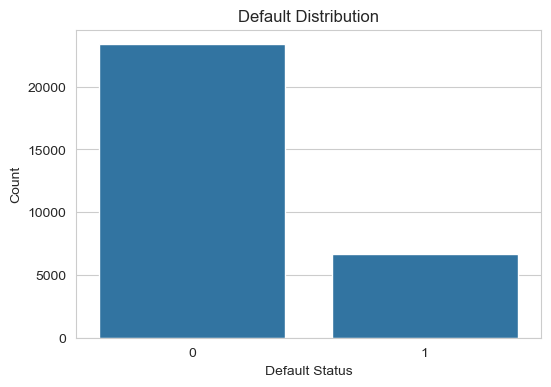

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x="DEFAULT", data=df)

plt.title("Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Count")

plt.savefig("../plots/default_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

The dataset exhibits class imbalance, where non-default cases significantly outnumber default cases. This is a common characteristic in financial risk datasets and indicates that evaluation metrics beyond accuracy will be important during modeling.


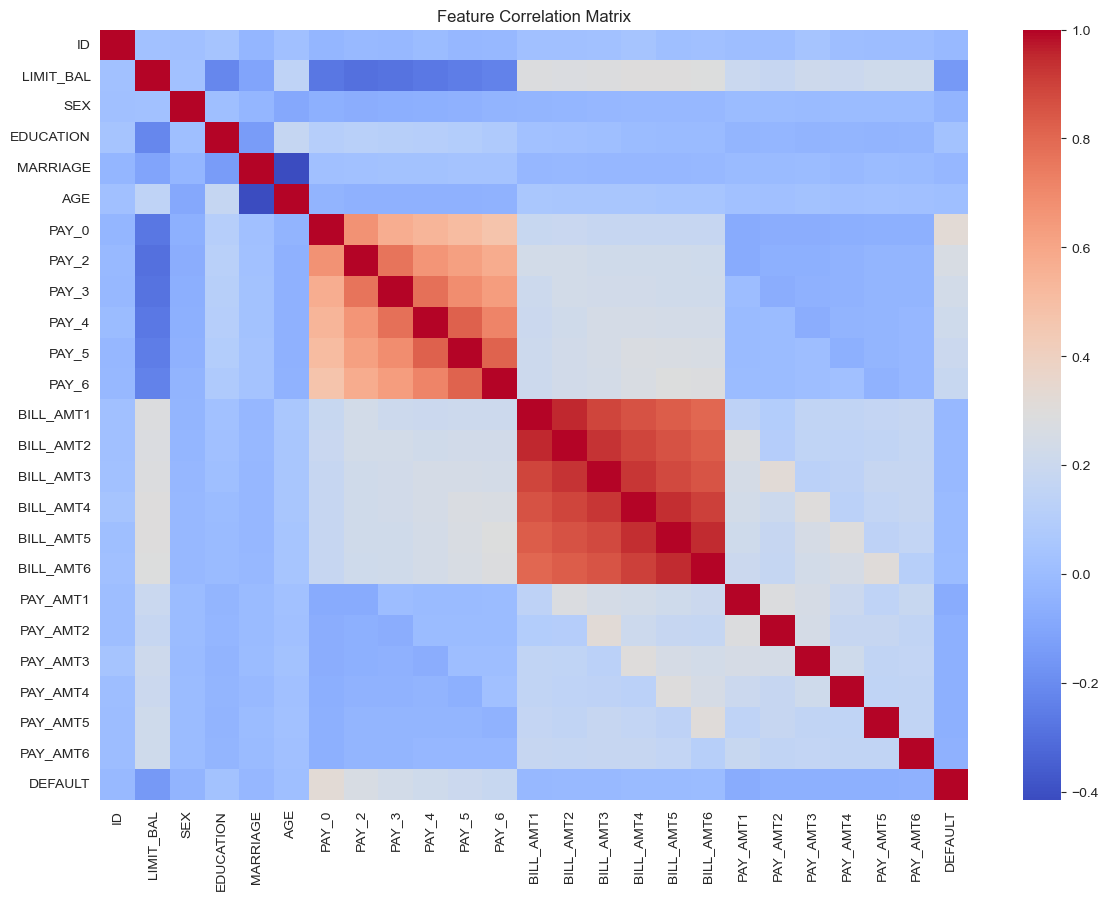

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature corelation Matrix")

plt.savefig("../plots/correlation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

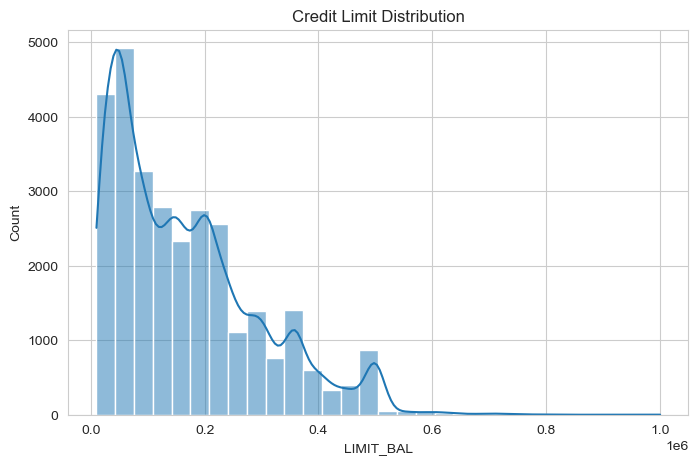

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df["LIMIT_BAL"], bins=30, kde=True)

plt.title("Credit Limit Distribution")

plt.savefig("../plots/credit_limit_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


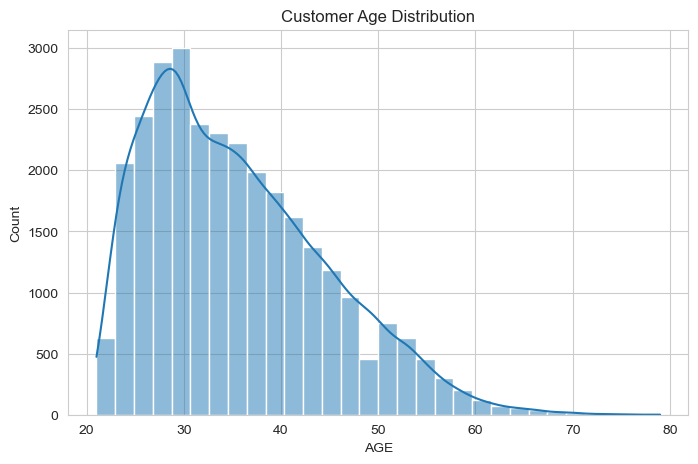

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["AGE"], bins=30, kde=True)

plt.title("Customer Age Distribution")

plt.savefig("../plots/age_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [30]:
bill_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]

pay_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]

In [31]:
df["AVG_BILL_AMT"] = df[bill_cols].mean(axis=1)

In [32]:
df["UTILIZATION_RATIO"] = df["AVG_BILL_AMT"] / df["LIMIT_BAL"]

In [33]:
pay_status_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

df["TOTAL_DELAY_MONTHS"] = (df[pay_status_cols] > 0).sum(axis=1)

## Feature Engineering

Additional behavioral financial indicators were engineered to capture customer repayment patterns, utilization pressure, and historical delinquency behavior. These features are designed to improve predictive signal quality for downstream machine learning models.

# Model Development

The next phase focuses on building predictive machine learning models to estimate the probability of customer default behavior.

In [34]:
X = df.drop("DEFAULT", axis=1)
y = df["DEFAULT"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [37]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [38]:
y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:,1]

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("F1 Score:", f1_score(y_test, y_pred_log))

print("ROC AUC:", roc_auc_score(y_test, y_prob_log))

Accuracy: 0.8066666666666666
F1 Score: 0.3995859213250518
ROC AUC: 0.7305929895013297


In [40]:
from xgboost import XGBClassifier

In [41]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [42]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("F1 Score:", f1_score(y_test, y_pred_xgb))

print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.7798333333333334
F1 Score: 0.5436960276338515
ROC AUC: 0.7806746608771292


In [44]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

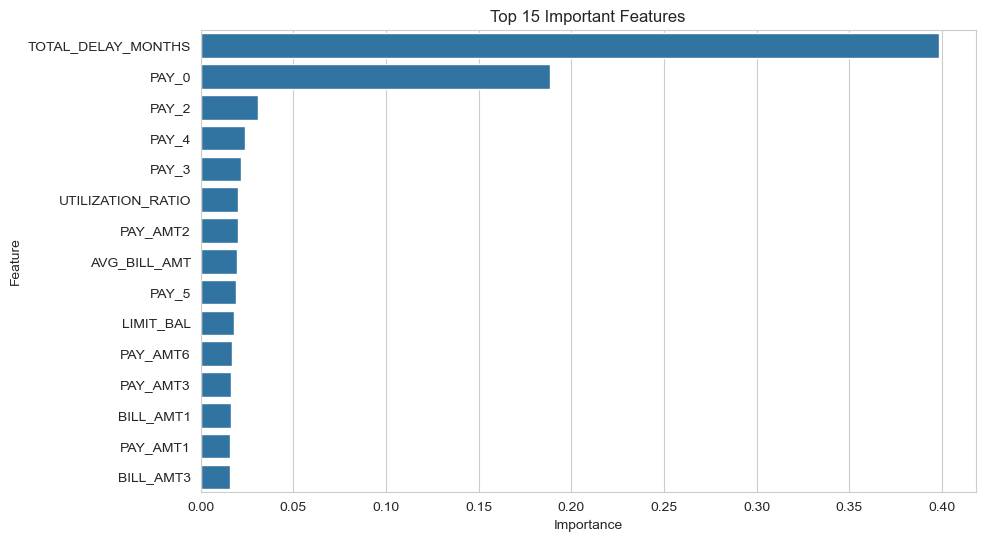

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.savefig("../plots/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

Recent repayment status variables and cumulative delinquency behavior emerged as the strongest predictors of default probability, highlighting the importance of temporal repayment behavior in digital lending risk assessment.

In [46]:
from sklearn.model_selection import cross_val_score

In [47]:
cv_auc = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Cross Validation AUC Scores:")
print(cv_auc)

print("Mean AUC:", cv_auc.mean())

Cross Validation AUC Scores:
[0.75713838 0.75814775 0.77201051 0.71716716 0.78110386]
Mean AUC: 0.7571135331979789
